#  Behind the Personality : Predicting Introversion & Extroversion .

In [3]:
import pandas as pd 
df = pd.read_csv("personality_dataset.csv")
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,3.0,Yes,2.0,0.0,Introvert


In [2]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='str')

In [47]:
df.shape

(2900, 8)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 220.9 KB


In [49]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(402)

In [51]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


 # EXPLORATORY DATA ANALYSIS

In [52]:
df["Personality"].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

<Axes: xlabel='Personality'>

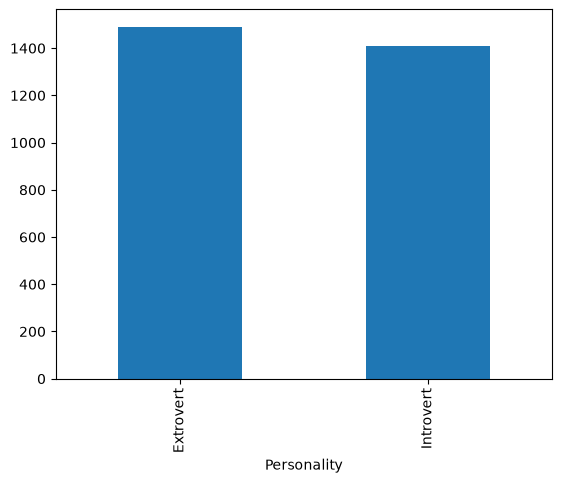

In [53]:
df["Personality"].value_counts().plot(kind = "bar")

# relationship

In [54]:
df.groupby("Personality")["Time_spent_Alone"].mean()

Personality
Extrovert    2.122869
Introvert    7.027444
Name: Time_spent_Alone, dtype: float64

### Introverts spend more time alone on average than extroverts

### visualization

<Axes: title={'center': 'Time_spent_Alone'}, xlabel='Personality'>

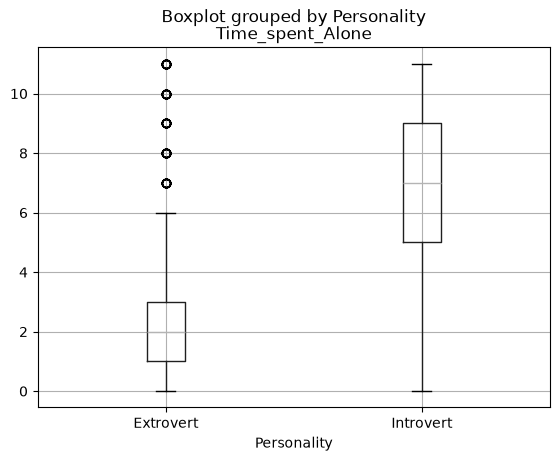

In [56]:
df.boxplot(column = "Time_spent_Alone" , by = "Personality")

In [57]:
df.groupby("Personality")["Social_event_attendance"].mean()

Personality
Extrovert    5.977850
Introvert    1.831621
Name: Social_event_attendance, dtype: float64

### Extroverts attend social events more frequently on average than introverts.

<Axes: title={'center': 'Social_event_attendance'}, xlabel='Personality'>

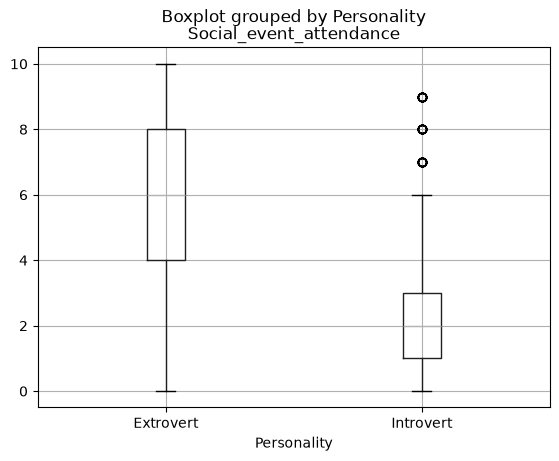

In [59]:
df.boxplot(column = "Social_event_attendance" , by = "Personality")

In [60]:
df.groupby("Personality")["Friends_circle_size"].mean()

Personality
Extrovert    9.095744
Introvert    3.277465
Name: Friends_circle_size, dtype: float64

<Axes: title={'center': 'Friends_circle_size'}, xlabel='Personality'>

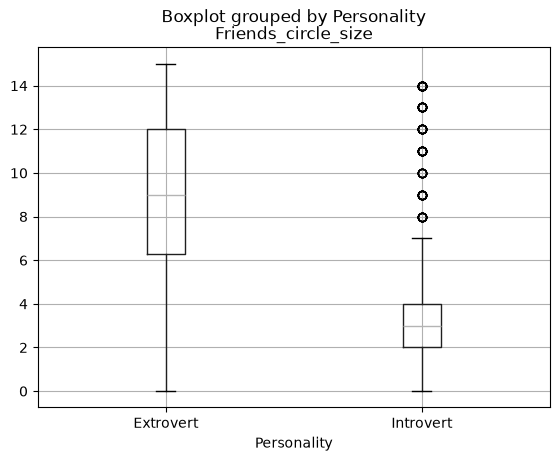

In [61]:
df.boxplot(column = "Friends_circle_size" , by = "Personality")

In [62]:
df.groupby("Personality")["Going_outside"].mean()

Personality
Extrovert    4.596244
Introvert    1.310859
Name: Going_outside, dtype: float64

<Axes: title={'center': 'Going_outside'}, xlabel='Personality'>

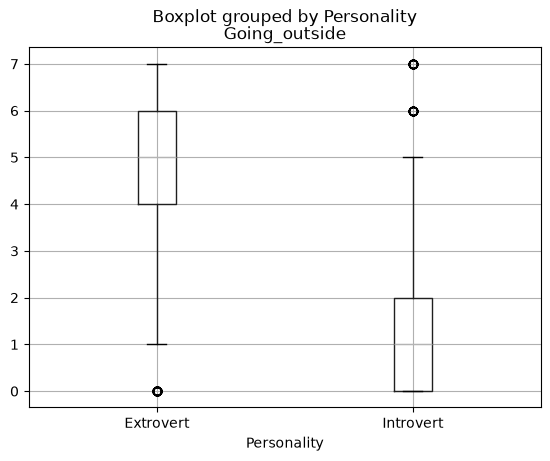

In [63]:
df.boxplot(column = "Going_outside" , by = "Personality")

In [64]:
pd.crosstab(df["Stage_fear"],df["Personality"] ,normalize = "columns")

Personality,Extrovert,Introvert
Stage_fear,,
No,0.925553,0.07807
Yes,0.074447,0.92193


In [65]:
df["Stage_fear"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [66]:
df["Drained_after_socializing"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [67]:
df["Personality"].unique()

<ArrowStringArray>
['Extrovert', 'Introvert']
Length: 2, dtype: str

In [68]:
df["Personality"] = df["Personality"].map({"Extrovert":1 , "Introvert": 0})                      

In [69]:
df["Personality"].unique()

array([1, 0])

In [70]:
X = df.drop("Personality" , axis = 1)
y = df["Personality"]

In [71]:
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,1
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,0
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,0
3,0.0,No,6.0,7.0,No,14.0,8.0,1
4,3.0,No,9.0,4.0,No,8.0,5.0,1
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,1
2896,3.0,No,8.0,3.0,No,14.0,9.0,1
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,0
2898,11.0,Yes,1.0,3.0,Yes,2.0,0.0,0


### Converting categorical values into numerical values:
### The Stage_fear column contains categorical values (Yes and No). Machine Learning models require numerical input, so we convert No to 0 and Yes to 1.

In [72]:
X["Stage_fear"] = X["Stage_fear"].map({"No":0 , "Yes":1})

In [73]:
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,1
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,0
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,0
3,0.0,No,6.0,7.0,No,14.0,8.0,1
4,3.0,No,9.0,4.0,No,8.0,5.0,1
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,1
2896,3.0,No,8.0,3.0,No,14.0,9.0,1
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,0
2898,11.0,Yes,1.0,3.0,Yes,2.0,0.0,0


### The original dataset (df) is kept unchanged. The encoded values are stored in X, which will be used as the input data for the Machine Learning model.

In [74]:
X["Stage_fear"].unique()

array([0, 1])

### Converting categorical values into numerical values:
### The Drained_after_socializing column contains categorical values (Yes and No). Machine Learning models require numerical input, so we convert No to 0 and Yes to 1.

In [75]:
X["Drained_after_socializing"] = X["Drained_after_socializing"].map({"No": 0,"Yes": 1})

In [76]:
X["Drained_after_socializing"].unique()

array([0, 1])

In [77]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.2 , random_state = 42)

### Building a Logistic Regression model:
Logistic Regression is suitable for this project because our target variable, Personality, has two possible classes: Introvert and Extrovert. The model will learn patterns from the training data and predict the personality class for new observations.

In [88]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit( X_train , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Making predictions on the test data:
We use the trained model to predict the Personality of observations in the test set. The test data was not used during training, so it allows us to evaluate the model on unseen data.

In [89]:
y_pred = model.predict(X_test)

### Evaluating the model accuracy:
Accuracy measures the percentage of predictions that match the actual target values. It helps us understand how well the model performs on unseen test data.

In [90]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test , y_pred)
print ("accuracy", accuracy)

accuracy 0.9241379310344827


### Checking the feature order:
Before we give the model a new person, we need to know the exact order of the features it learned from. The new values must follow the same order.

In [91]:
X.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency'],
      dtype='str')

In [92]:
new_person = [[5, 1, 4, 3, 0, 6, 5]]
new_person

[[5, 1, 4, 3, 0, 6, 5]]

In [93]:
new_person = pd.DataFrame([{
    "Time_spent_Alone": 5,
    "Stage_fear": 1,
    "Social_event_attendance": 4,
    "Going_outside": 3,
    "Drained_after_socializing": 0,
    "Friends_circle_size": 6,
    "Post_frequency": 5}])

In [94]:
prediction = model.predict(new_person)
prediction

array([1])

In [95]:
"Extrovert" if prediction[0] == 1 else "Introvert"

'Extrovert'

# THE UI

In [96]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [97]:
import joblib
joblib.dump(model, "personality_model.pk1")

['personality_model.pk1']

In [98]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Personality
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727,0.514138
std,3.441180,2.872608,2.221597,4.232340,2.893587,0.499886
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000,0.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000,1.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000,1.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000,1.000000
